In [13]:
import matplotlib.pyplot as plt

plt.imsave("../data/raw/test_product.png", x_test[0], cmap="gray")

print("Expected category:", class_names[y_test[0]])
print("Test image created.")

Expected category: Ankle boot
Test image created.


In [12]:
model.save("../app/models/product_classifier.h5")

print("Model saved successfully.")

Model saved successfully.


In [11]:
from pathlib import Path

print(Path.cwd())

/Users/anujanag/Documents/smart-retail-ai/notebooks


In [10]:
test_loss, test_accuracy = model.evaluate(x_test_cnn, y_test)

print("Test accuracy:", round(test_accuracy * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8853 - loss: 0.3248
Test accuracy: 88.53 %


In [9]:
history = model.fit(
    x_train_cnn,
    y_train,
    validation_data=(x_validation_cnn, y_validation),
    epochs=5,
    batch_size=128,
)

Epoch 1/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7664 - loss: 0.6465 - val_accuracy: 0.8518 - val_loss: 0.4237
Epoch 2/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8531 - loss: 0.4153 - val_accuracy: 0.8688 - val_loss: 0.3704
Epoch 3/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8696 - loss: 0.3663 - val_accuracy: 0.8798 - val_loss: 0.3354
Epoch 4/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8795 - loss: 0.3387 - val_accuracy: 0.8836 - val_loss: 0.3241
Epoch 5/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8872 - loss: 0.3178 - val_accuracy: 0.8906 - val_loss: 0.3063


In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
x_train_cnn = x_train[..., None]
x_validation_cnn = x_validation[..., None]
x_test_cnn = x_test[..., None]

print(x_train_cnn.shape)

(55000, 28, 28, 1)


In [6]:
x_validation = x_train[-5000:]
y_validation = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("Training images:", x_train.shape)
print("Validation images:", x_validation.shape)
print("Test images:", x_test.shape)

Training images: (55000, 28, 28)
Validation images: (5000, 28, 28)
Test images: (10000, 28, 28)


In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Smallest pixel value:", x_train.min())
print("Largest pixel value:", x_train.max())

Smallest pixel value: 0.0
Largest pixel value: 1.0


Matplotlib is building the font cache; this may take a moment.


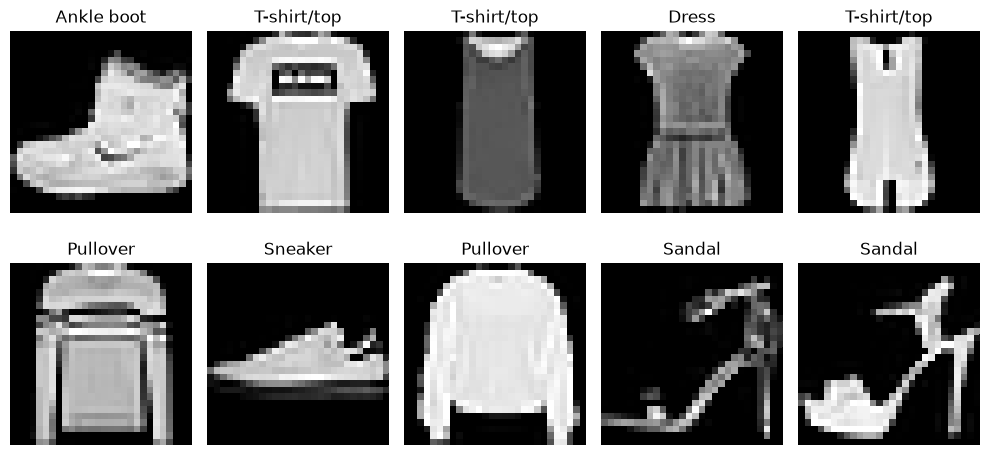

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for index in range(10):
    plt.subplot(2, 5, index + 1)
    plt.imshow(x_train[index], cmap="gray")
    plt.title(class_names[y_train[index]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [2]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 52s 2us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 3s 1us/step
Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0
